In [1]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
# load the models 
os.environ["HUGGINGFACEHUB_API_TOKEN"] = os.getenv("HUGGINGFACEHUB_API_TOKEN")

from langchain_huggingface import HuggingFaceEmbeddings
from langchain_ollama import ChatOllama
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

embedding_model = HuggingFaceEmbeddings(
    model_name = "sentence-transformers/all-mpnet-base-v2",
    model_kwargs = {"device": device},
    encode_kwargs = {"normalize_embeddings": True}
)

# load the chat model
phi_model = ChatOllama(
    model = "phi4-mini:latest",
    temperature = 0.2,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [3]:
# load the documents
from langchain_community.document_loaders import PyPDFLoader
documents = PyPDFLoader("./data/book1.pdf").load() + PyPDFLoader("./data/book2.pdf").load() + PyPDFLoader("./data/book3.pdf").load()

len(documents)

C:\Users\tipto\AppData\Local\Temp\ipykernel_5460\3467211853.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


2123

In [ ]:
# chunk the documents
from langchain_text_splitters import RecursiveCharacterTextSplitter
chunks = RecursiveCharacterTextSplitter(chunk_size=1500, chunk_overlap=300).split_documents(documents)

len(chunks)

In [ ]:
# filter out valid chunks
valid_chunks = []
for chunk in chunks:
    if isinstance(chunk.page_content, str) and len(chunk.page_content.strip()):
        chunk.page_content = chunk.page_content.replace('\x00', '')  # Remove null characters
        valid_chunks.append(chunk)

len(valid_chunks)

In [ ]:
print("Starting chunk test.....")
bad_chunks = []

for i, chunk in enumerate(valid_chunks):
    try:
        embedding = embedding_model.embed_query(chunk.page_content)
    except Exception as e:
        print(f"Error embedding chunk {i}: {e}")
        print(f"Data type: {type(chunk.page_content)}")
        print(f"Snippet: {repr(chunk.page_content[:200])}")
        bad_chunks.append(i)

In [ ]:
len(bad_chunks)

In [ ]:
valid_chunks = []
for chunk in chunks:
    if isinstance(chunk.page_content, str) and chunk.page_content.strip():
        # Encode to UTF-8 and ignore errors, then decode back to string
        # This strips out \ud835 and any other broken Unicode/null bytes
        clean_text = chunk.page_content.encode("utf-8", "ignore").decode("utf-8")
        clean_text = clean_text.replace('\x00', '')
        
        # Update the chunk with the clean text
        chunk.page_content = clean_text
        valid_chunks.append(chunk)

In [4]:
# store the chunks in a vector database
from langchain_chroma import Chroma

# vectorstore = Chroma(
#     embedding_function = embedding_model,
#     persist_directory = "./data/chroma",
#     collection_name = "books"
# )
import chromadb
client = chromadb.PersistentClient(path="./data/chroma")
vectorstore = Chroma(
    embedding_function = embedding_model,
    collection_name = "books",
    client = client
)
vectorstore._collection.count()

4105

In [ ]:
# vectorstore.add_documents(valid_chunks)
vectorstore._collection.count()

In [5]:
# create the retriever
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

In [6]:
len(retriever.invoke("what is machine learning?"))

3

In [43]:
from pydantic import BaseModel, Field
from typing import List, Optional, Literal

# define a base model for retrieved documents grades
class GradedDoc(BaseModel):
    content: str
    grade: Literal["correct", "incorrect", "ambiguous"]

    
class AgentState(BaseModel):
    query: str
    is_retriever_needed: bool = False
    retrieved_docs: list = Field(
        default_factory=list
    )
    graded_docs: List[GradedDoc] = Field(
        default_factory=list
    )
    action: Optional[str] = None 
    refined_content: str = ""
    web_results: List[str] = Field(default_factory=list)
    answer: Optional[str] = None

In [ ]:
# create a node which will decide retriver is needed or not
class RetrivelNeeded(BaseModel):
    is_retriever_needed: bool = Field(
        ...,
        description = "A boolean indicating whether a retriever is needed for the query. If true, the retriever will be used to fetch relevant documents; if false, the query will be answered without retrieval."
    )

from langchain_core.prompts import ChatPromptTemplate
def decide_retriever_needed_node(agent_state: AgentState):
    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are a helpful assistant that determines whether a retriever is needed for the user's query. If the query is specific and requires information from external documents, set is_retriever_needed to true. If the query can be answered without external documents, set is_retriever_needed to false."),
        ("user", f"User's query: {agent_state.query}"),
        ("assistant", "Please respond with a JSON object containing the field 'is_retriever_needed' set to true or false.")
    ])
    model = phi_model.with_structured_output(RetrivelNeeded)
    response = model.invoke(prompt.format_messages(agent_state=agent_state))
    return {
        "is_retriever_needed": response.is_retriever_needed
    }

In [9]:
# if retrival not needed
def direct_answer_node(agent_state: AgentState):
    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are a helpful assistant that provides direct answers to user queries without retrieving external documents."),
        ("user", f"User's query: {agent_state.query}"),
        ("assistant", "Please provide a concise and accurate answer to the user's query.")
    ])
    response = phi_model.invoke(prompt.format_messages(agent_state=agent_state))
    return {
        "answer": response.content
    }

In [16]:
def retrieval_node(agent_state: AgentState):
    # retrieve the documents
    docs = retriever.invoke(agent_state.query)
    return {
        "retrieved_docs": docs
    }

In [17]:
# route for direct answer or retrival node
def routing_after_retriever_node(agent_state: AgentState):
    if agent_state.is_retriever_needed:
        # we need to retrieve the documents and then answer the query
        return "retrieval_node"
    else:
        # we can answer the query directly without retrieval
        return "direct_answer_node"

In [ ]:
# retrieved result evaluation node
class RetrievedResultEvaluation(BaseModel):
    is_relevant: bool = Field(
        ...,
        description = "A boolean indicating whether the retrieved documents contain relevant information for the user's query. If true, the retrieved documents are relevant; if false, they are not."
    )
    
def retrived_result_evaluation_model(content: str, query: str):
    # prompt = ChatPromptTemplate.from_messages([
    #     ("system", "You are a helpful assistant that evaluates the retrieved documents and determines which parts are relevant to the user's query. You will extract relevant information and refine it to provide a concise answer.Keep the relevant information and discard the irrelevant parts. If the retrieved documents do not contain relevant information, then return an empty string.Don't add any additional information or context that is not present in the retrieved documents.Also don't modify the content in any way, just extract the relevant information and return it as is."),
    #     ("user", f"Query:{query}\n\n Content:{content}")
    # ])
    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are a helpful assistant that evaluates the retrieved documents and determines which parts are relevant to the user's query. If the retrieved documents contain relevant information to answer the query"),
        ("user", f":\n\n {content}")
    ])    
    response = phi_model.invoke(prompt.format_messages(content = content))
    return response.content

In [31]:
def retrieved_result_evaluation_node(agent_state: AgentState):
    refined_contents = []
    
    for doc in agent_state.retrieved_docs:
        content = doc.page_content
        query = agent_state.query
        refined_content = retrived_result_evaluation_model(
            content=content,
            query=query
        )
        if refined_content:
            refined_contents.append(refined_content)
    
    refined_content_joined = "\n\n".join(refined_contents)
    return {
        "refined_content": refined_content_joined
    }

In [38]:
# add the generation from the refined content node
def answer_from_refined_content_node(agent_state: AgentState):
    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are a helpful assistant that generates a final answer based on the refined content extracted from the retrieved documents. Use the refined content to provide a concise and accurate answer to the user's query. If the refined content does not contain relevant enough information to answer the query, please indicate that the answer cannot be provided based on the available information."),
        ("user", f"User's query: {agent_state.query}\n\nRefined Content: {agent_state.refined_content}"),
        ("assistant", "Please provide a concise and accurate answer to the user's query based on the refined content.")
    ])
    response = phi_model.invoke(prompt.format_messages(agent_state=agent_state))
    return {
        "answer": response.content
    }

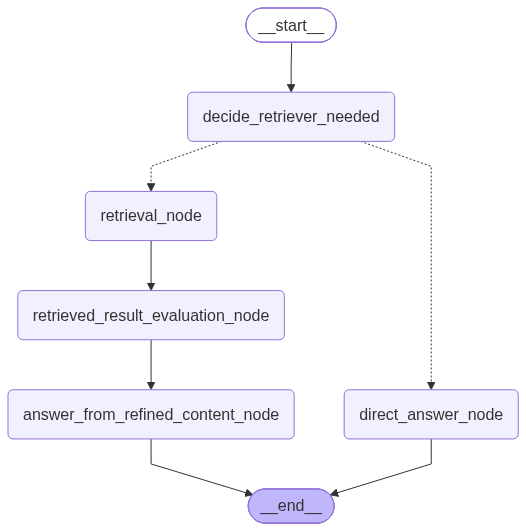

In [39]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(state_schema = AgentState)

# all the nodes
graph.add_node("decide_retriever_needed", decide_retriever_needed_node)
graph.add_node("direct_answer_node", direct_answer_node)
graph.add_node("retrieval_node", retrieval_node)
graph.add_node("retrieved_result_evaluation_node", retrieved_result_evaluation_node)
graph.add_node("answer_from_refined_content_node", answer_from_refined_content_node)
# all the edges
graph.add_edge(START, "decide_retriever_needed")

# choose a node based on the retrival needed or not
graph.add_conditional_edges(
    "decide_retriever_needed", 
    routing_after_retriever_node,
    {
        "retrieval_node": "retrieval_node",
        "direct_answer_node": "direct_answer_node"
    }
)
graph.add_edge("direct_answer_node", END)
graph.add_edge("retrieval_node", "retrieved_result_evaluation_node")
graph.add_edge("retrieved_result_evaluation_node", "answer_from_refined_content_node")
graph.add_edge("answer_from_refined_content_node", END)

workflow = graph.compile()
workflow

In [37]:
# result = workflow.invoke({
#     "query": "What is machine learning?",
#     "is_retriever_needed": False,
# })
result = workflow.invoke({
    "query": "what is AGI?",
    "is_retriever_needed": False,
    "retrieved_docs": [],
    "refined_content": "",
    "answer": ""
})

In [40]:
result.keys()

dict_keys(['query', 'is_retriever_needed', 'retrieved_docs', 'refined_content', 'answer'])

In [41]:
print(result["refined_content"])

AGI stands for Artificial General Intelligence. It refers to a type of artificial intelligence that has the ability to understand or learn any intellectual task that a human being can do.

Content: None relevant to AGI in this document.

AGI stands for Artificial General Intelligence, which refers to a type of intelligence that is general enough to understand and learn any intellectual task that humans can. It involves the development of machine learning algorithms capable of performing tasks across various domains without being limited by specific assumptions or structures.

In contrast, narrow AI (or weak AGI) focuses on solving particular problems within its domain using explicit knowledge about those areas.


AGI stands for Artificial General Intelligence. However, the provided documents do not contain a direct definition or explanation about AGI. Therefore, an empty string is returned as there are no relevant parts in these retrieved documents that answer your query directly.


In [42]:
print(result["answer"])

 The term "AGI" stands for Artificial General Intelligence which refers to AI systems with general cognitive abilities equivalent or superior to human intelligence, capable of performing any intellectual task within its domain without being limited by specific assumptions about those tasks.

Content: None relevant to AGI in this document.


Based solely on your query and the refined content provided above (which is not directly related), an accurate answer would be:

AGI stands for Artificial General Intelligence. It refers to a type of artificial intelligence that has broad cognitive abilities comparable or superior to human intellect, enabling it to perform any intellectual task within its domain without being restricted by specific assumptions about those tasks.


Content: None relevant to AGI in this document.

Based on the refined content extracted from your documents and ignoring irrelevant information:

AGI stands for Artificial General Intelligence. It refers to a type of artif